<a href="https://colab.research.google.com/github/dayurihti/reaction-time-extraction2/blob/main/reaction_time_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overview**

Welcome!

This reaction time extraction program was initially made to help process data from the “Picture Naming Task” experiment. Using this program, we are able to detect human speech onset from the mass audio files.

This program used amplitude-based measurement, detecting the 70% level of the highest amplitude. The cut-off was operationalized by considering the characteristic of human voice: the amplitude is consistently increasing until the peak. This characteristic is unique compared with the other kind of artifact noises.

**Data Sample**

There are 32 audio files, containing human voice naming objects with a single word. I recorded my voice as a sample, feel free to use them. :)

In [43]:
import glob

audio_all = glob.glob(f'{'/content/audio.all'}/*.wav')

print(audio_all[:10])
print(f'Total audio files: {len(audio_all)}')

['/content/audio.all/practice_ID_response2.wav', '/content/audio.all/practice_ID_response5.wav', '/content/audio.all/practice_SWITCHING_response2.wav', '/content/audio.all/practice_SWITCHING_response12.wav', '/content/audio.all/practice_SWITCHING_response3.wav', '/content/audio.all/practice_SWITCHING_response6.wav', '/content/audio.all/practice_SWITCHING_response15.wav', '/content/audio.all/practice_ID_response4.wav', '/content/audio.all/practice_SWITCHING_response7.wav', '/content/audio.all/practice_SWITCHING_response11.wav']
Total audio files: 32


**1. Detection**

Define general functions for RT detection, including the threshold, cut-offs, and flagging rules.

In [44]:
import numpy as np
import librosa
import os

def detect_relative_threshold_and_peak(
    audio_path,
    relative_ratio=0.7,     # RT is 70% level of the peak amplitude
    smooth_ms=5,
    min_rt=0.12,            # minimum speech onset (s)
    max_peak_gap=0.9        # maximum gap between RT and peak (s)
):
    # load audio
    signal, sr = librosa.load(audio_path, sr=None)

    # amplitude envelope
    envelope = np.abs(signal)

    win_length = max(int(sr * smooth_ms / 1000), 1)
    envelope = np.convolve(
        envelope,
        np.ones(win_length) / win_length,
        mode="same"
    )

    ## PEAK DETECTION ##
    peak_idx = np.argmax(envelope)
    peak_time = peak_idx / sr
    peak_value = envelope[peak_idx]

    relative_threshold = relative_ratio * peak_value

    # relative threshold & guard window
    crossing_indices = np.where(envelope >= relative_threshold)[0]

    rt_time = None
    for idx in crossing_indices:
        t = idx / sr

        if t < min_rt:                      # minimum speech onset
            continue
        if t > peak_time:                   # RT must happened before peak
            break
        if (peak_time - t) > max_peak_gap:  # RT - peak gap checking
            continue

        rt_time = t
        break

    # return dict
    return {
        "signal": signal,
        "envelope": envelope,
        "sr": sr,
        "rt": rt_time,
        "peak_time": peak_time,
        "rt_amplitude": relative_threshold
    }

## FLAGGING ##
def flag_trial(rt, peak_time):
    if rt is None:
        return "HARD_FLAG"
    if rt < 0.10 or rt > 2.10:
        return "HARD_FLAG"
    if rt < 0.20:
        return "SOFT_FLAG"
    if (peak_time - rt) > 0.9:
        return "SOFT_FLAG"
    return "-"

**2. Visualize**

Define settings for the visualization of audio waveform and RT.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def plot_waveform(audio_path):
    result = detect_relative_threshold_and_peak(audio_path)

    rt = result["rt"]
    peak_time = result["peak_time"]
    time = np.arange(len(result["signal"])) / result["sr"]

    plt.figure(figsize=(12, 4))
    plt.plot(time, result["signal"], color="gray", alpha=0.4, label="Waveform")
    plt.plot(time, result["envelope"], color="black", linewidth=1.2, label="Envelope")
    plt.axhline(result["rt_amplitude"], color="green", linestyle=":", label="Relative Threshold")

    if rt is not None:
        plt.axvline(rt, color="blue", linestyle="--", label="RT")
    plt.axvline(peak_time, color="red", linestyle="--", label="Peak")

    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.grid(True, which="major", alpha=0.6)
    ax.grid(True, which="minor", alpha=0.2)

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Peak-Validated Relative Threshold RT Detection")
    plt.legend()
    plt.tight_layout()
    plt.show()

**3. Export CSV**

Define settings for exporting RT data into CSV files.

In [46]:
import csv
import os

def export_to_csv(audio_files_list, output_csv):
    results = []

    for audio_path in sorted(audio_files_list):
        wav = os.path.basename(audio_path)
        result = detect_relative_threshold_and_peak(audio_path)
        flag = flag_trial(result["rt"], result["peak_time"])

        results.append({
            "file_name": wav,
            "relative_threshold_s": result["rt"],
            "peak_time_s": result["peak_time"],
            "flag": flag
        })

    with open(output_csv, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "file_name",
                "relative_threshold_s",
                "peak_time_s",
                "flag"
            ]
        )

        writer.writeheader()
        writer.writerows(results)

    print(f"\nSaved {len(results)} trials to '{output_csv}'")

**4. MAIN**

Please run this file to generate RT detection results in Terminal, show waveform from the individual audio files, and export the data into CSV files.


REACTION TIME DETECTION RESULT (Relative Threshold)

File Name                                | Relative Threshold (s) | Peak (s) |  FLAG
---------------------------------------------------------------------------
practice_ID_response2.wav                |   1.8346 |   1.8632 |     -
practice_ID_response5.wav                |   0.7288 |   0.7391 |     -
practice_SWITCHING_response2.wav         |   0.9219 |   0.9531 |     -
practice_SWITCHING_response12.wav        |   1.1352 |   1.1483 |     -
practice_SWITCHING_response3.wav         |   1.1404 |   1.2700 |     -
practice_SWITCHING_response6.wav         |   1.0439 |   1.0875 |     -
practice_SWITCHING_response15.wav        |   1.0502 |   1.1847 |     -
practice_ID_response4.wav                |   0.7701 |   0.8487 |     -
practice_SWITCHING_response7.wav         |   1.6117 |   1.6599 |     -
practice_SWITCHING_response11.wav        |   1.0821 |   1.0935 |     -
practice_SWITCHING_response9.wav         |   0.9015 |   0.9039 |     -
prac

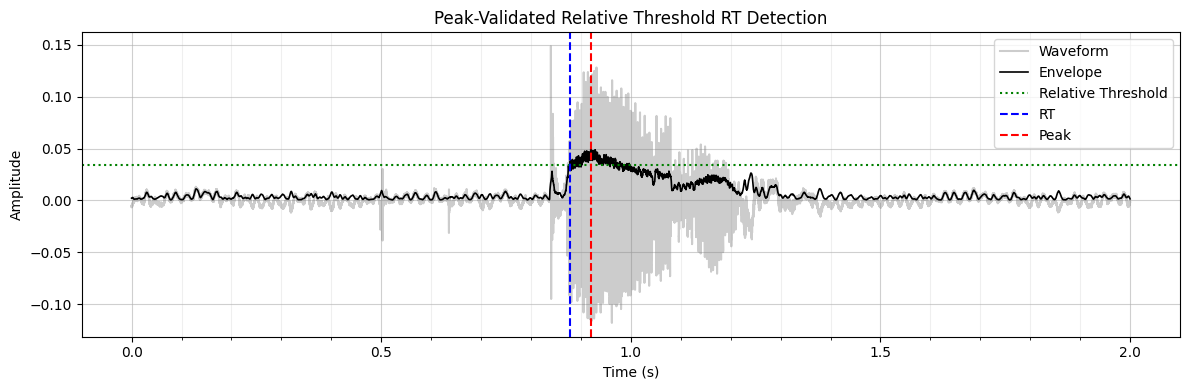

In [47]:
# terminal settings
def print_terminal_summary(audio_files_list):

# plot settings
    print("\nREACTION TIME DETECTION RESULT (Relative Threshold)\n")
    print(f"{'File Name':40s} | {'Relative Threshold (s)':>8s} | {'Peak (s)':>8s} | {'FLAG':>5s}")
    print("-" * 75)

    for audio_path in audio_files_list:
        wav_filename = os.path.basename(audio_path)
        result = detect_relative_threshold_and_peak(audio_path)
        flag = flag_trial(result["rt"], result["peak_time"])

        rt_str = f"{result['rt']:.4f}" if result["rt"] is not None else "NA"
        peak_str = f"{result['peak_time']:.4f}"

        print(f"{wav_filename:40s} | {rt_str:>8s} | {peak_str:>8s} | {flag:>5s}")

## RESULT ##
print_terminal_summary(audio_all)

export_to_csv(
    audio_all,
    "/content/rt_extraction.csv"
)

specific_audio_file = os.path.join(
    "/content/audio.all",
    "practice_EN_response6.wav"
)

plot_waveform(specific_audio_file)